# **Meshlands - Humidity**
One of the main purposes of this research project is to determine the moisture availability variations between the different experiments. Regarding the subject, this file provides all the necessary figures required to understand our results.
The notebook is organized as:
- Specific Humidity
- Relative Humidity
- Total Precipitable Water
- Soil Moisture

## **Initial Set Up-related**

### Imports

In [1]:
%matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt

########## Python Standard Library ##########
from copy import copy
import glob

########## Cartopy ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## SciPy ##########
import scipy.ndimage as ndi

########## Xarray ##########
import xarray as xr

### Function Definitions

In [2]:
# Overall: creates a new local mapping function that doesn't use basemap
def quick_map(mapdata,lat,lon,mesh,title=None,cb_ttl=None,cmap=None,clim=None,
              filepath=None,show=None,close=None,sigmask=None,p=None,
              do_zonal=None,
              outside_color = None, outside_val = None,extend='both'):
    '''
    Creates a new local mapping function that does not use a basemap
    '''
    # Makes 2 subplots: one for map, one for zonal average next to it
    fig = plt.figure(figsize=(15,15))

    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # ajouter une colonne cyclique
    xc_cyc = np.concatenate([mesh["xc"], mesh["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh["yc"], mesh["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh["mask"], mesh["mask"][:, :1]], axis=1)

    # Draws coastlines from this path : /arc/project/st-mlague-1/data/CESM/meshland/inputs/
    # ax.coastlines()
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be the entire globe
    ax.set_global()

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=lon)

    # Plots the data as a coloured mesh
    cs = plt.pcolormesh(cyclic_lons,lat,cyclic_data,transform=ccrs.PlateCarree())
    
    # If a cmap (colour map) is specified, copy and use it
    # Else, copy and use the viridis cmap
    if cmap:
        plt.set_cmap(copy(cmap))
    else:
        plt.set_cmap(copy(plt.cm.viridis))

    # If a title is specified, use it (also sets the font size and position)
    if title:
        plt.title(title,fontsize=16,y=1.05)

    # If a clim (colour limit) is specified, use it
    if clim:
        plt.cm.ScalarMappable.set_clim(cs,vmin = clim[0],vmax = clim[1])

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend=extend,pad=.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=15) 

    # If a cb_ttl (colour bar title) is specified, use it
    if cb_ttl:
        cbar.set_label(cb_ttl,fontsize=20)

    # Sets cm to the cmap
    cm = plt.get_cmap()
   
    # Overall: adds hatching for significance
    # If a p-value is specified, add 
    if p:

        # Creates a cyclic point to ensure longitude plots smoothly 
        cyclic_sig, cyclic_lons = add_cyclic_point(sigmask,coord=lon)

        # Creates a meshgrid using cyclic longitude and latitude coordinates
        CLN, CLT = np.meshgrid(cyclic_lons,lat)

        # Only puts the hatches where the sigmask is >0.5
        sigmask = np.where(cyclic_sig>p,1.0,np.nan)
        sigmask2 = np.ma.masked_where(cyclic_sig > p, sigmask)

        # Masks out insignificant latitude data
        lat_sig = np.ma.masked_where(cyclic_sig>p,CLT)

        # Masks out NaN latitude data
        lat_sig = np.ma.masked_where(np.isnan(cyclic_sig),lat_sig)

        # Masks out insignificant longitude data
        lon_sig = np.ma.masked_where(cyclic_sig>p,CLN)

        # Masks out NaN longitude data
        lon_sig = np.ma.masked_where(np.isnan(cyclic_sig),lon_sig)

        # Scatters markers
        hatch = ax.scatter(lon_sig,lat_sig,s=sigmask2,marker='x',#s=2,
                           c=[0.6, 0.6, 0.6],alpha=0.8,transform=ccrs.PlateCarree(),)

    # Add points at the center of each ocean group
    ocean_mask = (mesh['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers = []
    lat_centers = []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        # Interpolate coordinates assuming regular grid
        dlon = mesh['xc'][0, 1] - mesh['xc'][0, 0]
        dlat = mesh['yc'][1, 0] - mesh['yc'][0, 0]
        lon_center = mesh['xc'][0, 0] + x * dlon
        lat_center = mesh['yc'][0, 0] + y * dlat
        lon_centers.append(lon_center)
        lat_centers.append(lat_center)

    ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=5, transform=ccrs.PlateCarree())
    
    # Sets the alpha value
    ax.patch.set_alpha(0.0)

    # Add a line at the bottom of the plot to draw the separation with the following plot
    line = plt.Line2D([0.1, 0.9], [0.12, 0.12], transform=fig.transFigure, color='black')
    fig.add_artist(line)
    
    # If show is specified, show the plot
    if show:
        plt.show()

    # If filepath is specified, save the figured to the file path
    if filepath:
        fig.savefig(filepath+'.png',dpi=300,facecolor=None,edgecolor=None,bbox_inches='tight',transparent=True,pad_inches=0.01)

    # Closes the plot
    if close:
        plt.close()

    # Returns the figure
    return fig,ax,cs,cbar,cm

###########

# Overall : calculates the global mean, ocean mean and land mean
def mean(ds_case,mask,var):
    '''
    Calculates the global, ocean and land mean of a given variable for a given configuration.

    Args:
        ds_case (xarray): dictionnary containing lat and lon dimensions.
        mask (list): representation of continental distribution, with value 1 if land and value 0 if ocean.
        var (str): name of the variable that needs to be averaged.

    Returns:
        gm (float OR array): global mean (can be an array if ds_case contains others dimensions).
        lm (float OR array): land mean (can be an array if ds_case contains others dimensions).
        om (float OR array): ocean mean (can be an array if ds_case contains others dimensions).
    '''

    # Collects the datas to plot the surface temperature
    mapdata = ds_case[var].mean('year')
    
    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case[var].lat))
    weights.name = "weights"
    
    # Finds the weighted global mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon')).values

    # Defines a land timeseries where the land mask is present
    land = mapdata.where(mask == 1)

    # Defines an ocean timeseries where the land mask is not present (i.e. just ocean/water)
    ocean = mapdata.where(mask != 1)

    # Mean Land
    lm = land.weighted(weights).mean(('lat', 'lon')).values

    # Mean Ocean
    om = ocean.weighted(weights).mean(('lat', 'lon')).values

    return gm, lm, om

############

def get_mapdata(ds, row):
    '''
    Calculates a mapdata depending on the row of the plot (only used in one plot)
    '''
    if row == 0:
        return ds['LHFLX'].mean('year')
    elif row == 1:
        return ds['TMQ'].mean('year')
    elif row == 2:
        return (ds['PRECL'].mean('year') + ds['PRECC'].mean('year'))*86400*365.25*1000

### Path Definitions

In [3]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [4]:
# Creates a list of atmospheric variables
atm_vars = ['Q','RELHUM','TMQ','LHFLX','PRECC','PRECL','T','VQ','TS']#,'TS','TREFHT','LNDV','TMQ','LHFLX','SHFLX','FSNS','FSDS','FLNS','FLDS']

# Creates a list of land variables
lnd_vars = ['H2OSOI']

### Dictionary Definitions

In [5]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [6]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric and land variables
ts_dict_atm = {}
ts_dict_lnd = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []
        file_list_lnd = [] 

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # For each variables in the set of land variables
        for var in lnd_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.clm2.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the land file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_lnd.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')
        ds_temp_lnd = xr.open_mfdataset(file_list_lnd,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
            ds_temp_lnd_short = ds_temp_lnd.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))
            ds_temp_lnd_short = ds_temp_lnd.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)
        ts_dict_lnd[short] = copy(ds_temp_lnd_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short, ds_temp_lnd, ds_temp_lnd_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


# **Specific Humidity**
This figure represents the zonally averaged specific humidity for all experiments. The contours are based on temperatures that impact the relative humidity (see below).

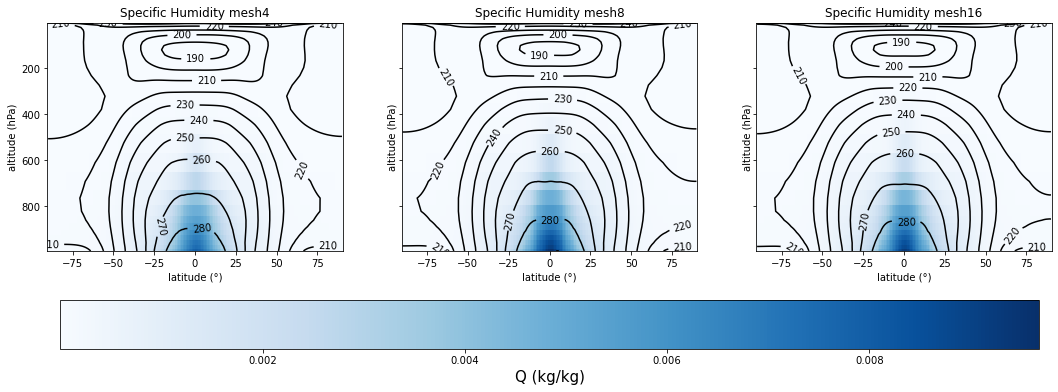

In [7]:
# Overall: creates 3 plots to show specific humidity at each latitude and altitude (mean by longitude)

# Creates a list containing all the data needed for the plotting
plot_data = []
for case in config :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    Q = ds_case['Q'].mean('year').mean('lon')
    T = ds_case['T'].mean('year').mean('lon')
    
    # Fills the list with a 2-tuple containing the case and the mapdata 
    plot_data.append((case,Q,T))

# Shared color limits for the same scale across all plots
# Calculates the min and max value of all Q for the colorbar
vmin = min(float(Q.min().values) for (case, Q, T) in plot_data)
vmax = max(float(Q.max().values) for (case, Q, T) in plot_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (case, Q, T) in zip(axes, plot_data):
    lat = Q['lat']
    lev = Q['lev']
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, Q, cmap='Blues', vmin=vmin, vmax=vmax, shading='auto')

    # Draws contours of temperature
    cs = ax.contour(lat, lev, T, levels=10, linestyles=None, colors='k')
    ax.clabel(cs, fmt="%d", fontsize=10, inline=True)
    
    ax.set_title(f'Specific Humidity {case}')
    ax.set_xlabel('latitude (°)')
    ax.set_ylabel('altitude (hPa)')
    # Reverts the y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('Q (kg/kg)',fontsize=15)
plt.show()
plt.close()

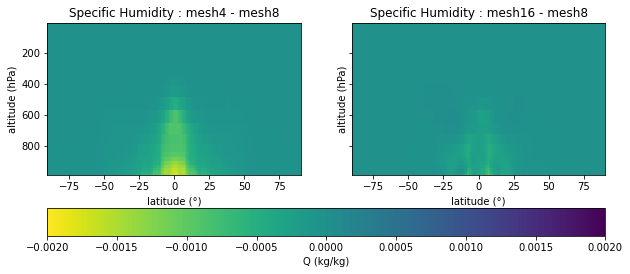

In [8]:
# Overall: plots the differences between cases with a reference case

# Defines the reference case (mesh8)
ref = ts_dict_atm['mesh8'].groupby('time.year').mean('time')

plot_data = []
# Collects the data avoiding the reference one (already collected above) and calculates the difference
for case in ['mesh4','mesh16'] :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    Q = ds_case['Q'].mean('year').mean('lon') - ref['Q'].mean('year').mean('lon')
    plot_data.append((case,Q))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of Q for the colorbar
vmin = min(float(Q.min().values) for (case,Q) in plot_data)
vmax = max(float(Q.max().values) for (case,Q) in plot_data)

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

for ax, (case, Q) in zip(axes, plot_data):
    lat = Q['lat']
    lev = Q['lev']
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, Q, cmap='viridis_r', vmin=-0.002, vmax=0.002, shading='auto')
    
    ax.set_title(f'Specific Humidity : {case} - mesh8')
    ax.set_xlabel("latitude (°)")
    ax.set_ylabel("altitude (hPa)")
    # Reverts the y-axis
    ax.set_ylim(lev.max().values, lev.min().values)
    ax.tick_params()

cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('Q (kg/kg)')
cb.ax.tick_params()

plt.show()
plt.close()

# **Relative Humidity**

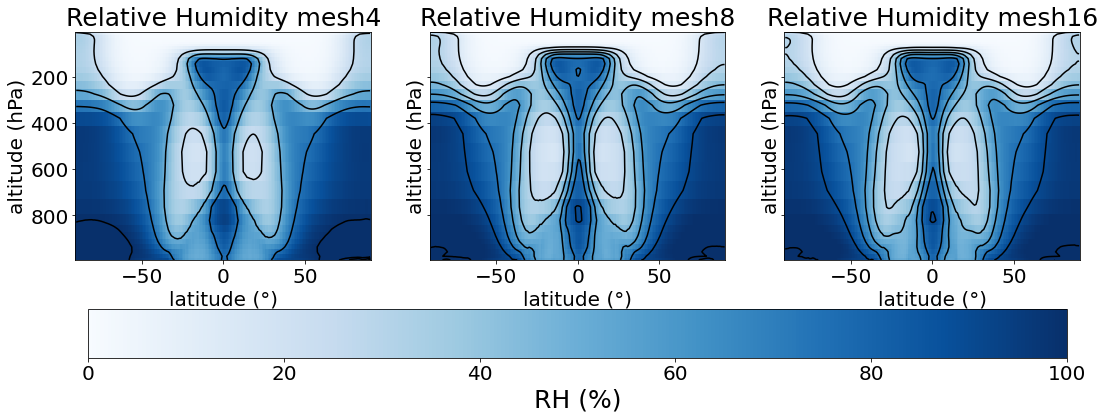

In [9]:
# Overall: creates 3 plots to show relative humidity at each latitude and altitude (mean by longitude)

# Creates a list containing all the data needed for the plotting
plot_data = []
for case in config :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    RH = ds_case['RELHUM'].mean('year').mean('lon')
    
    # Fills the list with a 2-tuple containing the case and the mapdata 
    plot_data.append((case,RH))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (case, RH) in zip(axes, plot_data):
    lat = RH['lat']
    lev = RH['lev']
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, RH, cmap='Blues', vmin=0., vmax=100., shading='auto')

    # Draws contours
    cs = ax.contour(lat, lev, RH, levels=10, linestyles=None, colors='k')
    
    ax.set_title(f'Relative Humidity {case}', fontsize=25)
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    # Reverts the y-axis
    ax.set_ylim(lev.max().values, lev.min().values)
    ax.tick_params(labelsize=20)

cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('RH (%)',fontsize=25)
cb.ax.tick_params(labelsize=20)

plt.show()
plt.close()

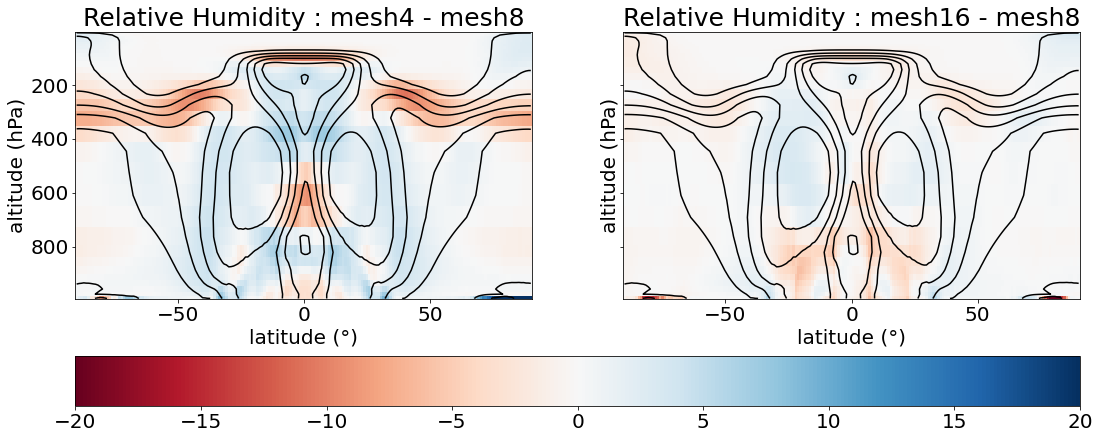

In [10]:
# Overall: plots the differences between cases with a reference case

# Defines the reference case (mesh8)
ref = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
RH_ref = ref['RELHUM'].mean('year').mean('lon')

plot_data = []
# Collects the data avoiding the reference one (already collected above) and calculates the difference
for case in ['mesh4','mesh16'] :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    RH = ds_case['RELHUM'].mean('year').mean('lon') - ref['RELHUM'].mean('year').mean('lon')
    plot_data.append((case,RH))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of Q for the colorbar
vmin = min(float(RH.min().values) for (case,RH) in plot_data)
vmax = max(float(RH.max().values) for (case,RH) in plot_data)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, (case, RH) in zip(axes, plot_data):
    lat = RH['lat']
    lev = RH['lev']
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, RH, cmap='RdBu', vmin=-20., vmax=20., shading='auto')

    # Draws contours of reference
    cs = ax.contour(lat, lev, RH_ref, levels=10, linestyles=None, colors='k')
    
    ax.set_title(f'Relative Humidity : {case} - mesh8',fontsize=25)
    ax.set_xlabel("latitude (°)", fontsize=20)
    ax.set_ylabel("altitude (hPa)", fontsize=20)
    # Reverts the y-axis
    ax.set_ylim(lev.max().values, lev.min().values)
    ax.tick_params(labelsize=20)

cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.ax.tick_params(labelsize=20)

plt.show()
plt.close()

# **Total precipitable water**


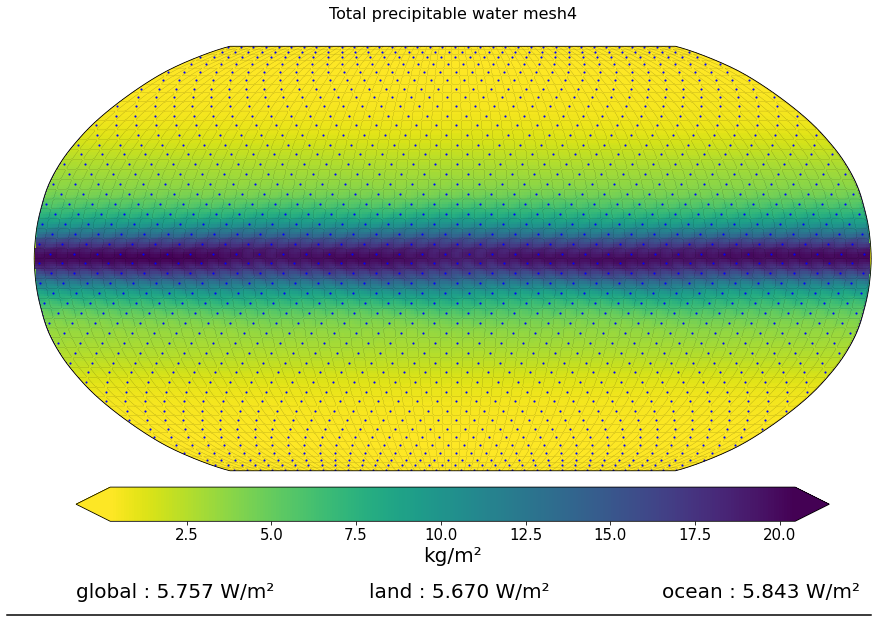

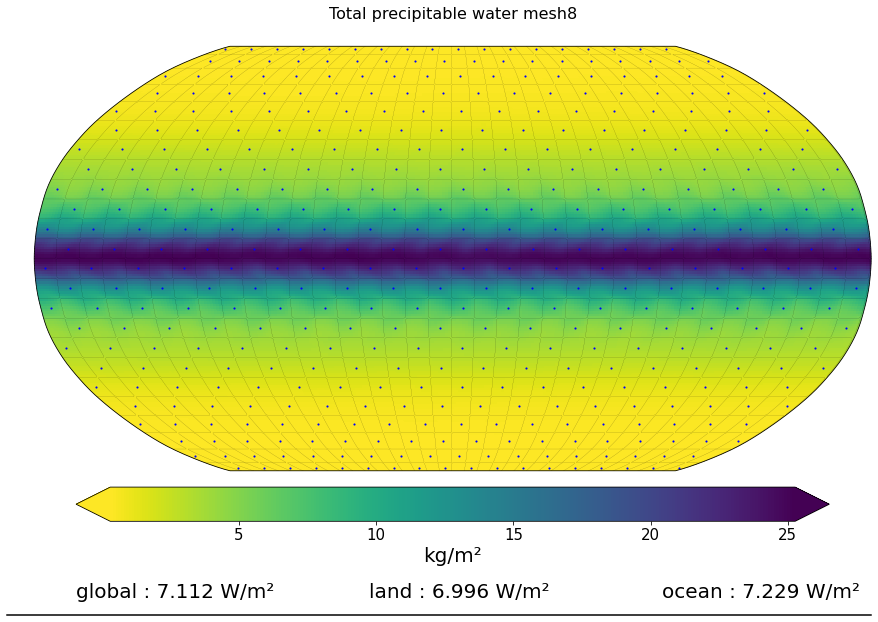

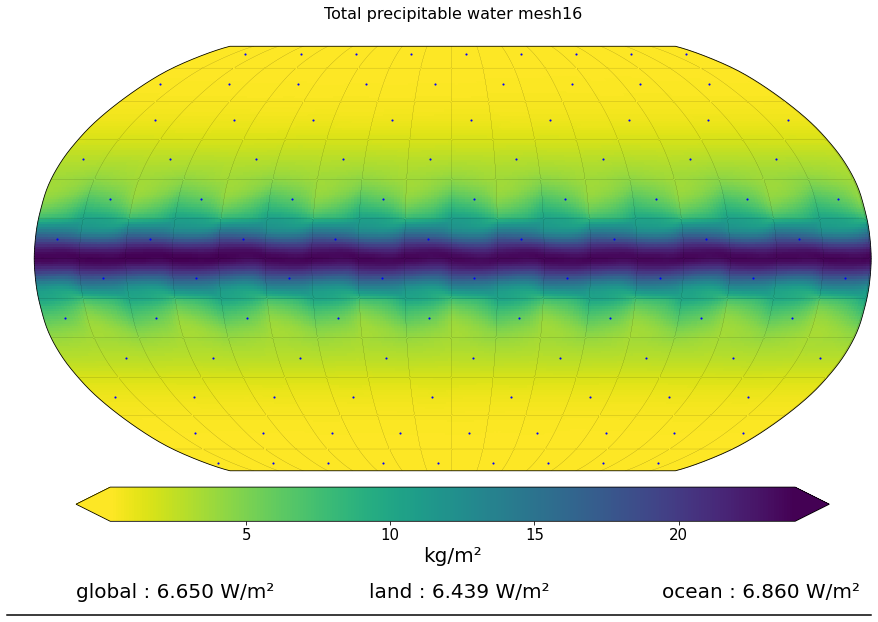

In [11]:
# Overall: plots the total precipitable water in the atmosphere separately for each experiment using the predefined quick_map

for case in config:
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the value of total precipitable water averaged over time
    mapdata = ds_case['TMQ'].mean('year')

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
    # Uses the mean function
    gm, lm, om = mean(ds_case, mask, 'TMQ')
    
    # Sets the plot's title
    ttl = 'Total precipitable water %s'%(case)

    # Sets the cmap colour
    cmap = plt.cm.get_cmap('viridis_r')

    # Uses the quick_map function (defined previously) to create the plot
    fig, ax, cs, cbar, cm = quick_map(mapdata,mapdata.lat,mapdata.lon,mesh_dict[case],title=ttl,cb_ttl='kg/m²',
              cmap=cmap,clim=None,
                  filepath=None,show=None,close=None,sigmask=None,p=None,
                  do_zonal=None,
                  outside_color = None, outside_val = None,extend='both')

    # Annotates the subplot with the global mean, land mean, and ocean mean
    ax.text(0.05, -0.3, 'global : %1.3f W/m²'%gm, transform=ax.transAxes, fontsize=20)
    ax.text(0.4, -0.3, 'land : %1.3f W/m²'%lm, transform=ax.transAxes, fontsize=20)
    ax.text(0.75, -0.3, 'ocean : %1.3f W/m²'%om, transform=ax.transAxes, fontsize=20)    

    plt.show()
    plt.close()

# **Soil Moisture**
Soil moisture is the only variable plotted from CLM5 in this research project. A particularity of the variable H2OSOI is that it contains a depth dimension (levsoi) that corresponds to the soil layers. According to this version of the Community Land Model, the levsoi dimension equivalents in terms of length are summarized in the table below.

| Layer index | Layer depth (m) | Layer depth (cm) |
|:-----------:|:---------------:|:-----------------:|
| 1  | 0.02  | 2    |
| 2  | 0.04  | 4    |
| 3  | 0.06  | 6    |
| 4  | 0.08  | 8    |
| 5  | 0.12  | 12   |
| 6  | 0.16  | 16   |
| 7  | 0.20  | 20   |
| 8  | 0.24  | 24   |
| 9  | 0.28  | 28   |
| 10 | 0.32  | 32   |
| 11 | 0.36  | 36   |
| 12 | 0.4   | 40   |
| 13 | 0.44  | 44   |
| 14 | 0.54  | 54   |
| 15 | 0.64  | 64   |
| 16 | 0.74  | 74   |
| 17 | 0.84  | 84   |
| 18 | 0.94  | 94   |
| 19 | 1.04  | 104  |
| 20 | 1.14  | 114  |

/home/mrodri10/.conda/envs/mland_xr/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/mrodri10/.conda/envs/mland_xr/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


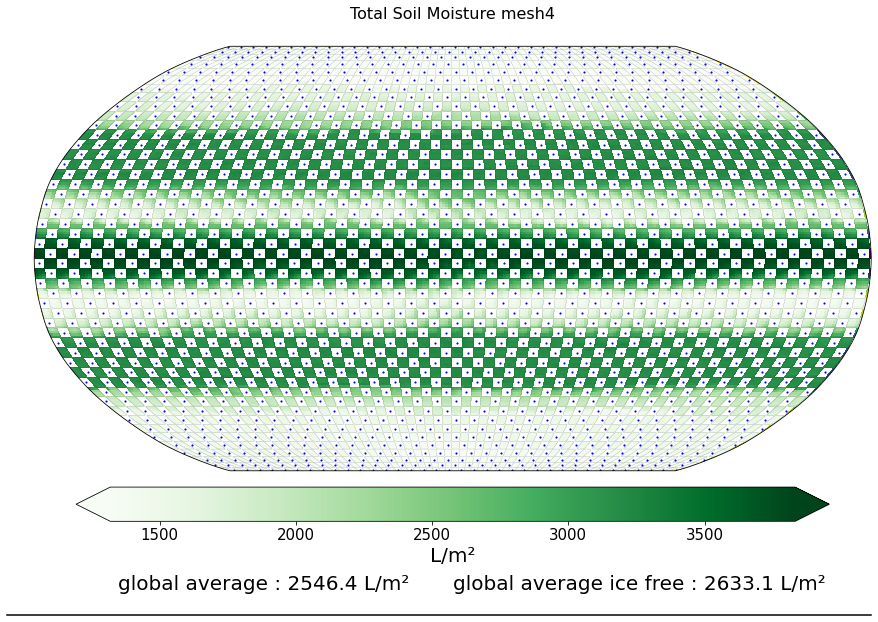

/home/mrodri10/.conda/envs/mland_xr/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/mrodri10/.conda/envs/mland_xr/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


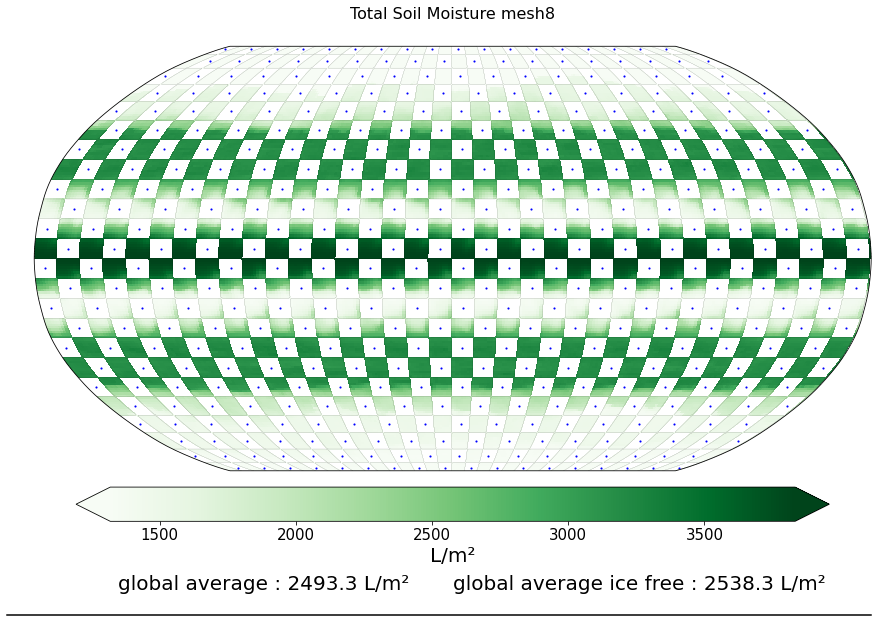

/home/mrodri10/.conda/envs/mland_xr/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/mrodri10/.conda/envs/mland_xr/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


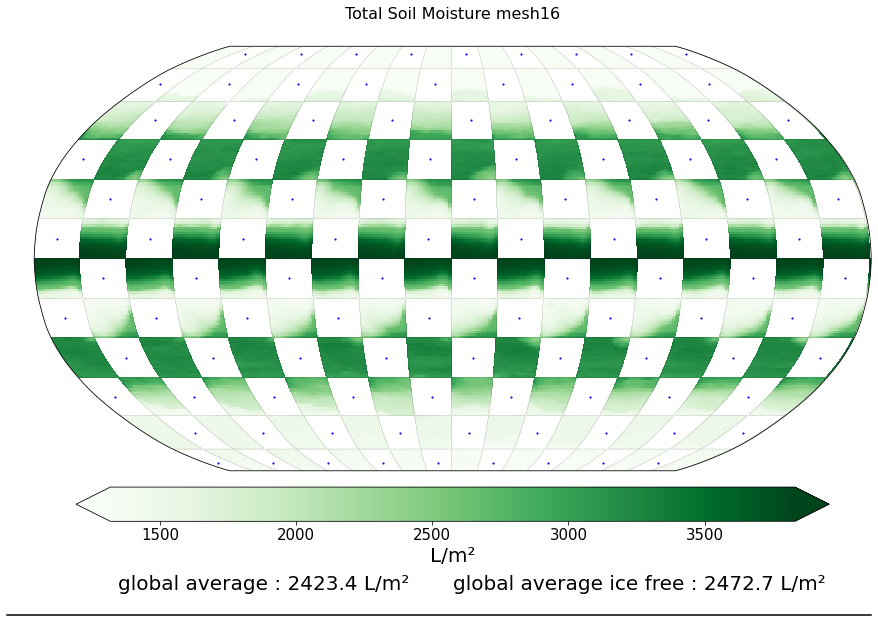

In [12]:
# Overall: plots separately the total moisture contained in a soil grid cell for each patch size

# Defines the layers' depth
soil_depth = [0.02,0.04,0.06,0.08,
              0.12,0.16,0.20,0.24,0.28,0.32,0.36,0.4,0.44,
              0.54,0.64,0.74,0.84,0.94,1.04,1.14]

for case in config:

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_lnd[case].groupby('time.year').mean('time')

    # Calculates the value of moisture integrated vertically (soil)
    mapdata = ds_case['H2OSOI'].mean('year').isel(levsoi=0) * soil_depth[0] * 1e3 
    for _,layer in enumerate(ds_case.levsoi.values[1:]):
        mapdata += ds_case['H2OSOI'].mean('year').isel(levsoi=layer) * soil_depth[layer] *1e3
    
    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case['H2OSOI'].lat))
    weights.name = "weights"
    
    # Finds the weighted global and the subtropics mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon')).values
    gm_trop = mapdata[64:-63,:].weighted(weights).mean(('lat','lon')).values
    
    # Sets the plot's title
    ttl = 'Total Soil Moisture %s'%(case)

    # Sets the cmap colour
    cmap = plt.cm.get_cmap('Greens')

    # Uses the quick_map function (defined previously) to create the plot
    fig, ax, cs, cbar, cm = quick_map(mapdata,mapdata.lat,mapdata.lon,mesh_dict[case],title=ttl,cb_ttl='L/m²',
              cmap=cmap,clim=None,
                  filepath=None,show=None,close=None,sigmask=None,p=None,
                  do_zonal=None,
                  outside_color = None, outside_val = None,extend='both')

    # Annotates the subplot with the total land mean, and the subtropics land mean
    ax.text(0.1, -0.28, 'global average : %1.1f L/m²'%gm, transform=ax.transAxes, fontsize=20)
    ax.text(0.5, -0.28, 'global average ice free : %1.1f L/m²'%gm_trop, transform=ax.transAxes, fontsize=20)
    
    plt.show()
    plt.close()

/home/mrodri10/.conda/envs/mland_xr/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/mrodri10/.conda/envs/mland_xr/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/mrodri10/.conda/envs/mland_xr/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


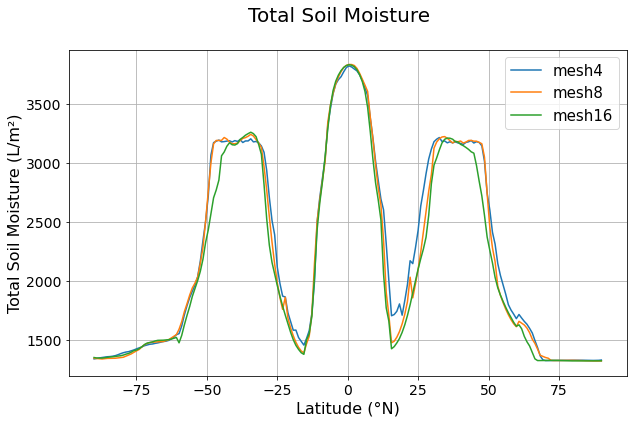

In [13]:
# Overall: plots the longitude-averaged soil moisture for every experiment

plt.figure(figsize=(10,6))
plt.suptitle('Total Soil Moisture', fontsize=20)

for case in config :

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_lnd[case].mean('time')

    # Calculates the value of moisture integrated vertically (soil)
    mapdata = ds_case['H2OSOI'].isel(levsoi=0) * soil_depth[0] * 1e3 
    for _,layer in enumerate(ds_case.levsoi.values[1:]):
        mapdata += ds_case['H2OSOI'].isel(levsoi=layer) * soil_depth[layer] *1e3
    
    plt.plot(mapdata.lat,mapdata.mean('lon'),label=case)

plt.grid()
plt.xlabel('Latitude (°N)',fontsize=16)
plt.ylabel('Total Soil Moisture (L/m²)',fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=15)
plt.show()
plt.close()